# Sistema de Pricing Predictivo para PLD
## Exploración de data y resultados

Este notebook genera la data sintética (calibrada con fuentes públicas de
BCRP, SBS e INEI — ver `data/external/fuentes.md`), entrena los dos
modelos del sistema, y muestra el resultado de negocio central: cuánto
margen adicional genera personalizar la tasa por cliente frente a una
tasa fija de mercado.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

from src.generar_data_sintetica import generar_clientes, TASA_MERCADO_PROMEDIO, COSTO_FONDEO
from src.modelo_riesgo import entrenar as entrenar_riesgo
from src.modelo_elasticidad import entrenar as entrenar_elasticidad
from src.pricing_engine import PricingEngine, PerfilCliente
from src.optimizador_pricing import optimizar_tasa

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Generación de data sintética

In [2]:
df = generar_clientes(n=20_000)
df.to_csv("../data/synthetic/clientes_pld_sintetico.csv", index=False)

print(f"Clientes generados: {len(df):,}")
print(f"Tasa de aceptación observada: {df['acepto'].mean():.1%}")
print(f"Morosidad observada (entre aceptados): {df.loc[df['acepto']==1, 'default'].mean():.1%}  (referencia SBS sistema: 4.8%)")
print(f"Tasa ofrecida promedio: {df['tasa_ofrecida'].mean():.1%}  |  Tasa mercado (peers SBS): {TASA_MERCADO_PROMEDIO:.1%}")
df.head()

Clientes generados: 20,000
Tasa de aceptación observada: 61.0%
Morosidad observada (entre aceptados): 4.9%  (referencia SBS sistema: 4.8%)
Tasa ofrecida promedio: 17.8%  |  Tasa mercado (peers SBS): 18.6%


,cliente_id,ingreso_mensual,score_riesgo,monto_solicitado,plazo_meses,tasa_ofrecida,tasa_mercado_referencia,costo_fondeo,acepto,default
0,1,"2,343.8200",0.7943,"5,800.0000",24,0.2229,0.1863,0.0425,1,0.0000
1,2,"1,111.9600",0.5965,"6,100.0000",24,0.1900,0.1863,0.0425,1,0.0000
2,3,"3,001.0100",0.3152,"2,200.0000",48,0.1627,0.1863,0.0425,1,0.0000
3,4,"3,334.6500",0.3873,"17,600.0000",48,0.1610,0.1863,0.0425,0,NaN
4,5,930.0000,0.8715,"3,300.0000",36,0.2446,0.1863,0.0425,0,NaN


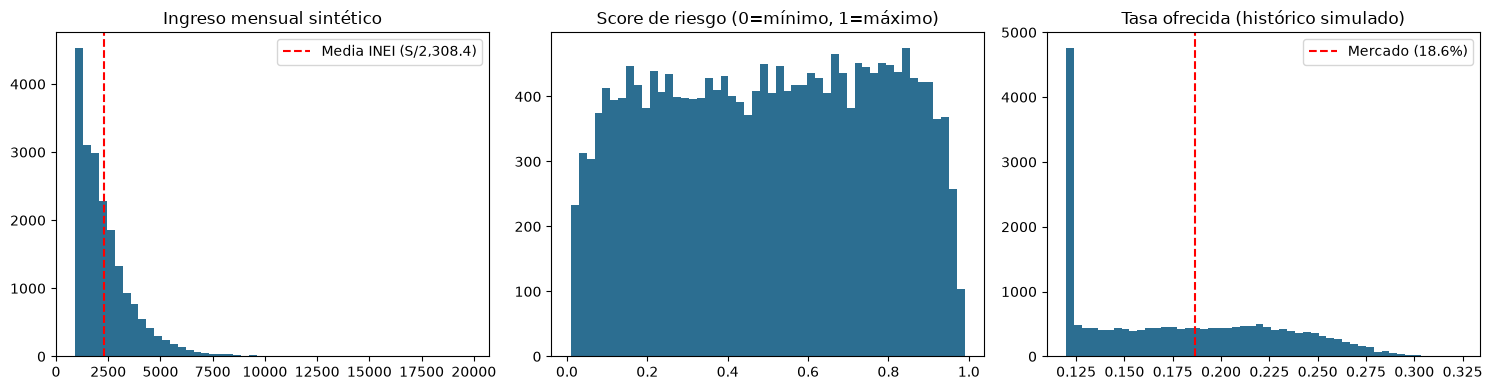

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["ingreso_mensual"], bins=50, color="#2c6e91")
axes[0].axvline(2308.4, color="red", linestyle="--", label="Media INEI (S/2,308.4)")
axes[0].set_title("Ingreso mensual sintético")
axes[0].legend()

axes[1].hist(df["score_riesgo"], bins=50, color="#2c6e91")
axes[1].set_title("Score de riesgo (0=mínimo, 1=máximo)")

axes[2].hist(df["tasa_ofrecida"], bins=50, color="#2c6e91")
axes[2].axvline(TASA_MERCADO_PROMEDIO, color="red", linestyle="--", label=f"Mercado ({TASA_MERCADO_PROMEDIO:.1%})")
axes[2].set_title("Tasa ofrecida (histórico simulado)")
axes[2].legend()

plt.tight_layout()
plt.savefig("distribuciones_sinteticas.png", dpi=100)
plt.show()

## 2. Entrenamiento de modelos

In [4]:
modelo_riesgo, auc_riesgo = entrenar_riesgo()
modelo_elasticidad, auc_elasticidad = entrenar_elasticidad()

print(f"AUC modelo de riesgo:       {auc_riesgo:.4f}")
print(f"AUC modelo de elasticidad:  {auc_elasticidad:.4f}")

2026/09/16 06:04:44 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/16 06:04:44 INFO mlflow.store.db.utils: Updating database tables


2026/09/16 06:04:45 INFO mlflow.tracking.fluent: Experiment with name 'modelo_riesgo_pld' does not exist. Creating a new experiment.


2026/09/16 06:04:45 INFO mlflow.tracking.fluent: Experiment with name 'modelo_elasticidad_pld' does not exist. Creating a new experiment.


Modelo de riesgo entrenado. AUC (test): 0.7540
Guardado en: /home/claude/pricing-pld-ml/models/modelo_riesgo.joblib
Run registrado en MLflow -> /home/claude/pricing-pld-ml/mlflow.db


Modelo de elasticidad entrenado. AUC (test): 0.7013
Guardado en: /home/claude/pricing-pld-ml/models/modelo_elasticidad.joblib
Run registrado en MLflow -> /home/claude/pricing-pld-ml/mlflow.db
AUC modelo de riesgo:       0.7540
AUC modelo de elasticidad:  0.7013


## 3. La curva de decisión — un cliente ejemplo

Esta es la pieza central del proyecto: para un cliente dado, cómo cambia
el margen esperado según la tasa que se le ofrezca, y dónde está el
óptimo.

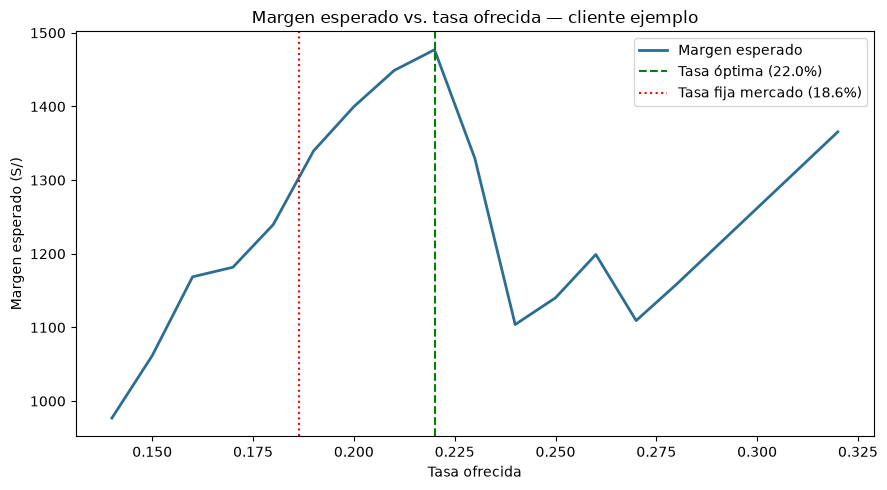

Tasa óptima: 22.0%  |  Margen esperado: S/ 1,477


In [5]:
cliente_ejemplo = PerfilCliente(score_riesgo=0.35, ingreso_mensual=3500, monto_solicitado=15000, plazo_meses=36)

resultado = optimizar_tasa(
    cliente_ejemplo.score_riesgo, cliente_ejemplo.ingreso_mensual,
    cliente_ejemplo.monto_solicitado, cliente_ejemplo.plazo_meses,
    modelo_elasticidad, modelo_riesgo,
)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(resultado.curva["tasa"], resultado.curva["margen_esperado"], color="#2c6e91", linewidth=2, label="Margen esperado")
ax1.axvline(resultado.tasa_optima, color="green", linestyle="--", label=f"Tasa óptima ({resultado.tasa_optima:.1%})")
ax1.axvline(TASA_MERCADO_PROMEDIO, color="red", linestyle=":", label=f"Tasa fija mercado ({TASA_MERCADO_PROMEDIO:.1%})")
ax1.set_xlabel("Tasa ofrecida")
ax1.set_ylabel("Margen esperado (S/)")
ax1.set_title("Margen esperado vs. tasa ofrecida — cliente ejemplo")
ax1.legend()
plt.tight_layout()
plt.savefig("curva_decision_cliente_ejemplo.png", dpi=100)
plt.show()

print(f"Tasa óptima: {resultado.tasa_optima:.1%}  |  Margen esperado: S/ {resultado.margen_esperado:,.0f}")

## 4. Resultado de negocio: mejora agregada de portafolio

In [6]:
from src.evaluar_portafolio import evaluar

df_res, margen_optimo, margen_mercado, mejora_pct = evaluar(n_muestra=500)

Muestra evaluada: 500 clientes
Margen esperado total — motor de pricing:      S/ 563,151
Margen esperado total — tasa fija de mercado:   S/ 415,804
Mejora agregada: +35.4%


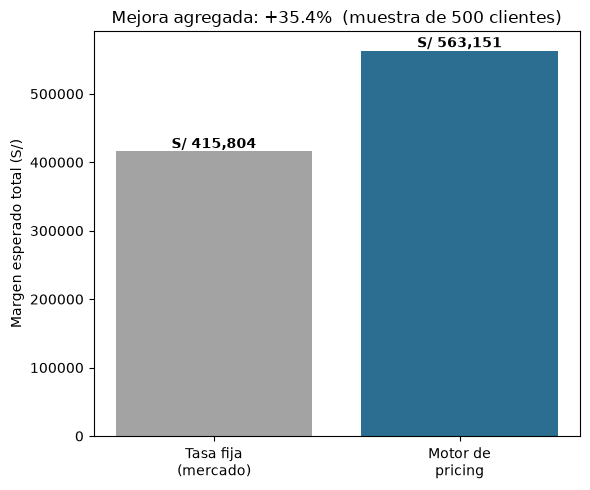

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Tasa fija\n(mercado)", "Motor de\npricing"], [margen_mercado, margen_optimo], color=["#a3a3a3", "#2c6e91"])
ax.set_ylabel("Margen esperado total (S/)")
ax.set_title(f"Mejora agregada: +{mejora_pct:.1f}%  (muestra de 500 clientes)")
for i, v in enumerate([margen_mercado, margen_optimo]):
    ax.text(i, v + 5000, f"S/ {v:,.0f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("mejora_portafolio.png", dpi=100)
plt.show()

## Conclusión

Personalizar la tasa por cliente (en vez de una tasa fija igual al
promedio de mercado) genera una mejora de margen esperado agregado de
**+35.4%** en la muestra evaluada. El detalle completo de fuentes,
supuestos y limitaciones está en el `README.md` del repositorio y en
`data/external/fuentes.md`.